In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from region import Region
from functions import Functions
fns = Functions()

In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import pickle
from cartopy.feature import LAND
from scipy.stats import pearsonr
import seaborn as sns

In [4]:
elevation_ = GEBCO(coarsen_factor=4).ds.elevation

In [5]:
extent_ac = [138,152,-68,-63]
extent_ea = [60,160,-70,-60]

elevation_ea = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))
elevation_ac = elevation_.sel(latitude = slice(extent_ac[2], extent_ac[3]), longitude = slice(extent_ac[0],extent_ac[1]))

In [20]:
with open('detrended_vars.pickle', 'rb') as handle:
    detrended_vars = pickle.load(handle)

detrended_vars.keys()

dict_keys(['Easterlies', 'Westerlies', 'ACC', 'Shelf SLA', 'Shelf SIC', 'Gyre Index', 'SAM Index', 'ASC', 'Shelf mean temperature (SOSE)', 'Shelf mean salinity (SOSE)', 'Shelf mean temperature (GLORYS)', 'Shelf mean salinity (GLORYS)', 'Shelf surface temperature (SOSE)', 'Shelf surface salinity (SOSE)', 'Shelf surface temperature (GLORYS)', 'Shelf surface salinity (GLORYS)', 'Shelf break temperature (SOSE)', 'Shelf break salinity (SOSE)', 'Shelf break temperature (GLORYS)', 'Shelf break salinity (GLORYS)', 'Shelf break density difference (SOSE)'])

Rendering..


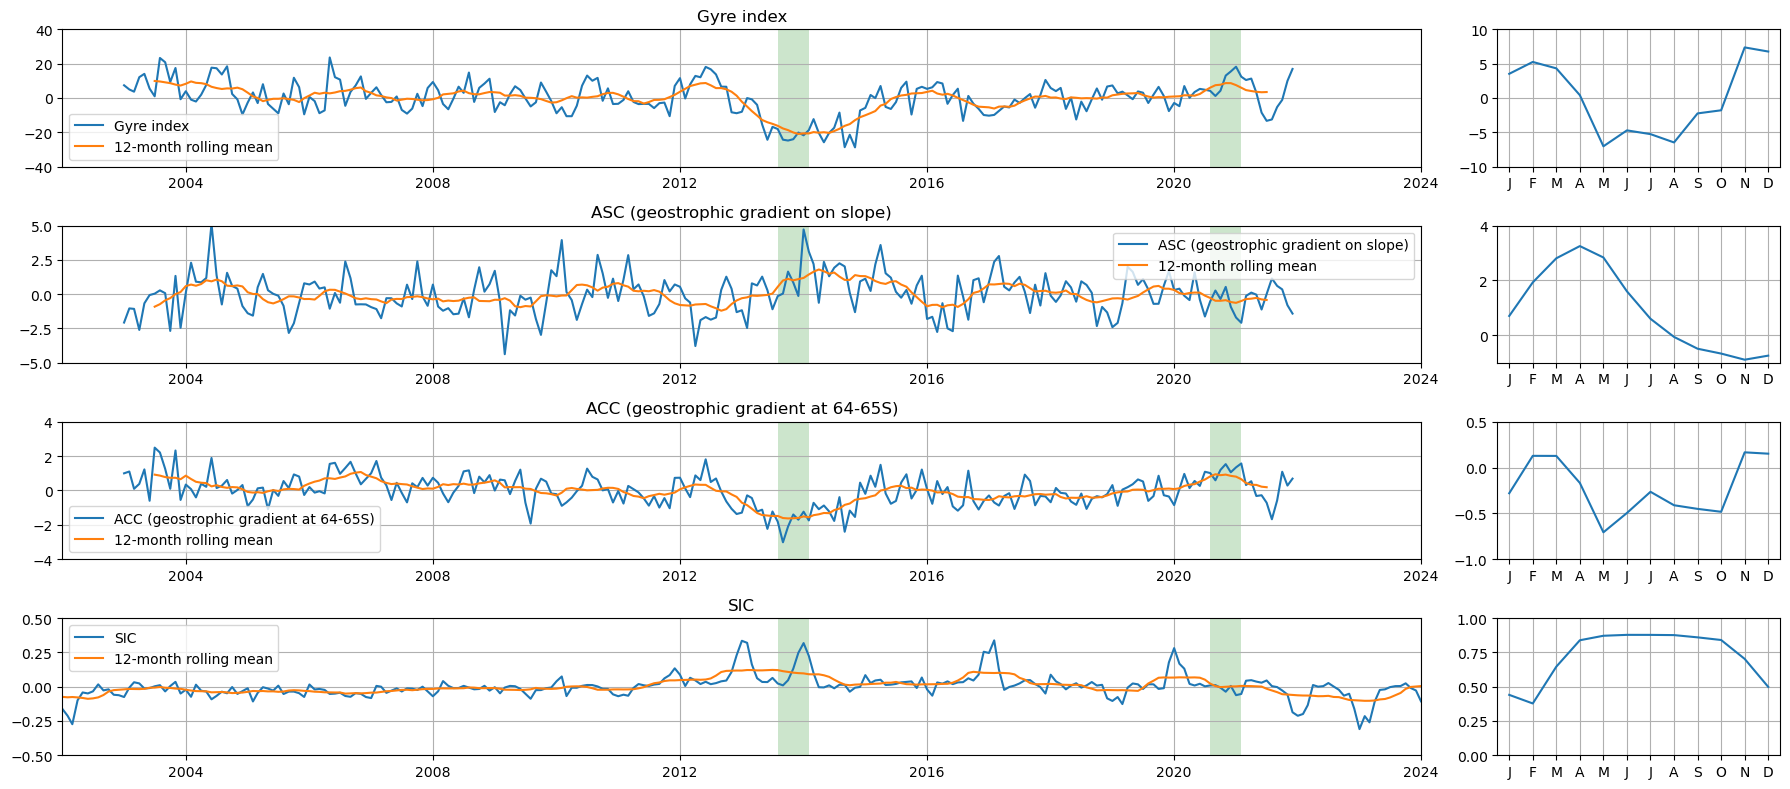

In [27]:
fig = plt.figure(figsize=(18,8))
axs=[]

gs = fig.add_gridspec(4,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    # for y,c in zip([2007,2011,2014,2017],colors):
    #     t1a = pd.Timestamp(y,10,1)
    #     t1b = pd.Timestamp(y+1,1,1)
    #     tboo = (da.time > t1a) & (da.time < t1b)
        
    #     ax.fill_between(da.time, ylim[0],ylim[1], where=tboo, alpha=0.4, facecolor=c,label='spring '+str(y))

    for y in [2013,2020]: 
        #if y==2014:
        t1a = pd.Timestamp(y,7,1)
        t1b = pd.Timestamp(y+1,3,1)
        # else:
        #     t1a = pd.Timestamp(y,1,1)
        #     t1b = pd.Timestamp(y+1,1,1)
        tboo = (da.time > t1a) & (da.time < t1b)
        
        ax.fill_between(da.time, ylim[0],ylim[1], where=tboo, alpha=0.2, facecolor='green',label='spring '+str(y))

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])




add_row(0,gyre_index,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-10,10])
add_row(1,asc,'ASC (geostrophic gradient on slope)',anom=True,ylim=[-5,5],ylim_cmt=[-1,4])
add_row(2,acc,'ACC (geostrophic gradient at 64-65S)',anom=True,ylim=[-4,4],ylim_cmt=[-1,0.5])
add_row(3,csic,'SIC',anom=True,ylim=[-0.5,0.5],ylim_cmt=[0,1])





plt.tight_layout()
print('Rendering..')


Rendering..


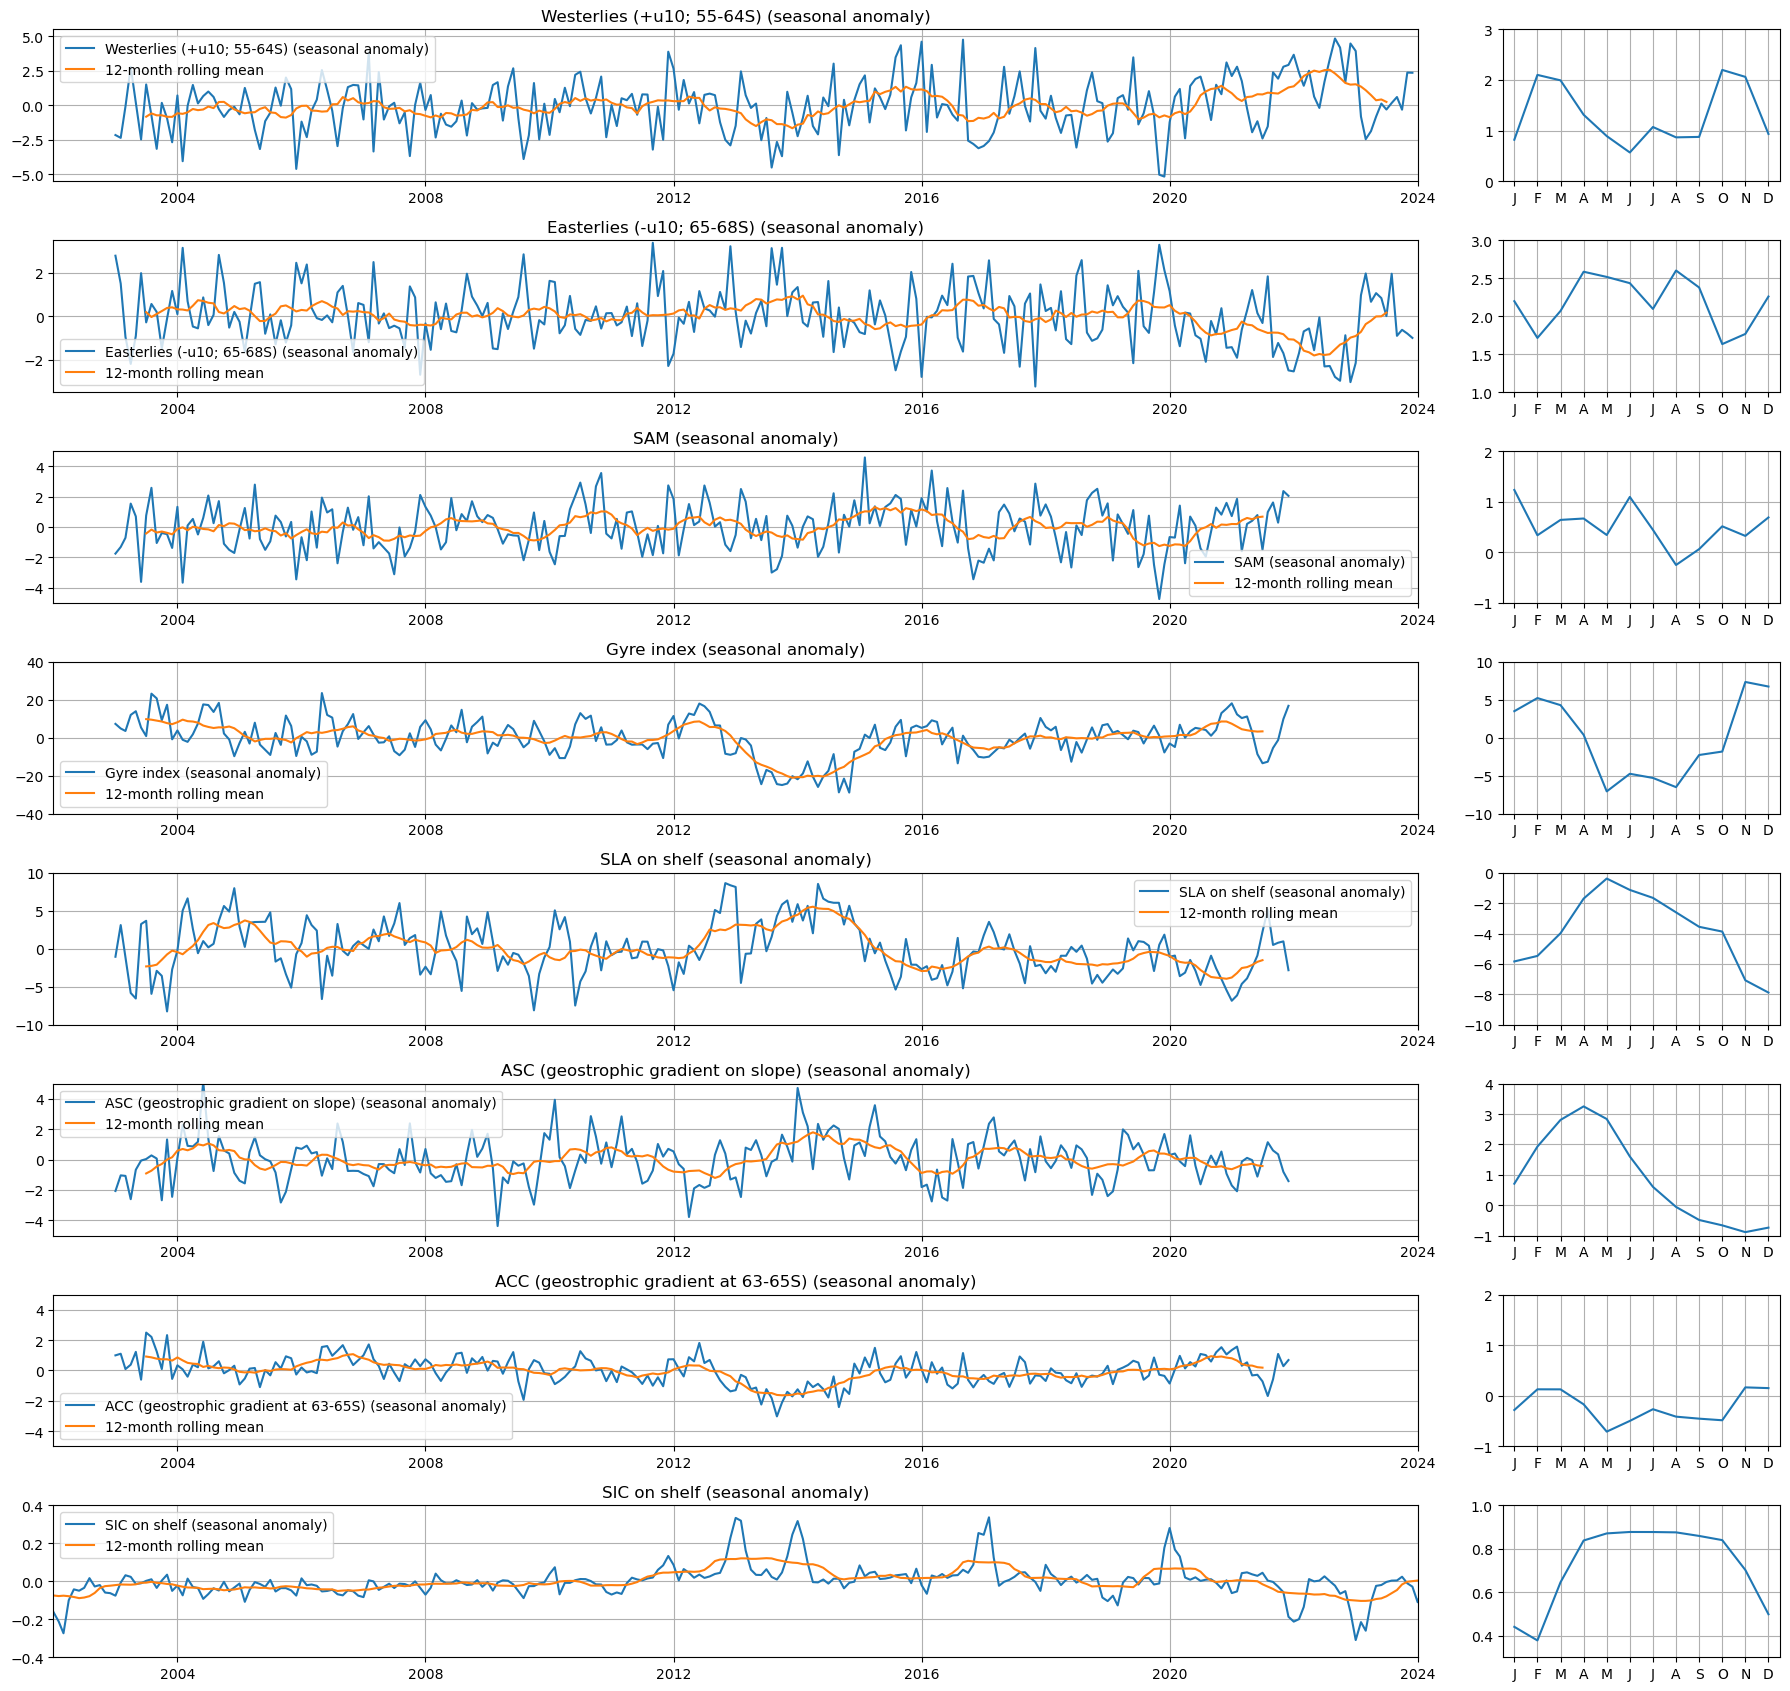

In [28]:
fig = plt.figure(figsize=(18,21))
axs=[]

gs = fig.add_gridspec(10,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    # for y,c in zip([2007,2011,2014,2017],colors):
    #     t1a = pd.Timestamp(y,10,1)
    #     t1b = pd.Timestamp(y+1,1,1)
    #     tboo = (da.time > t1a) & (da.time < t1b)
        
    #     ax.fill_between(da.time, ylim[0],ylim[1], where=tboo, alpha=0.4, facecolor=c,label='spring '+str(y))

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])



add_row(0,westl,'Westerlies (+u10; 55-64S)',anom=True,ylim=[-5.5,5.5],ylim_cmt=[0,3])
add_row(1,eastl,'Easterlies (-u10; 65-68S)',anom=True,ylim=[-3.5,3.5],ylim_cmt=[1,3])
add_row(2,sam,'SAM',anom=True,ylim=[-5,5],ylim_cmt=[-1,2])
add_row(3,gyre_index,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-10,10])
add_row(4,cssh,'SLA on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])
add_row(5,asc,'ASC (geostrophic gradient on slope)',anom=True,ylim=[-5,5],ylim_cmt=[-1,4])
add_row(6,acc,'ACC (geostrophic gradient at 63-65S)',anom=True,ylim=[-5,5],ylim_cmt=[-1,2])
add_row(7,sic_shelf,'SIC on shelf',anom=True,ylim=[-0.4,0.4],ylim_cmt=[0.3,1])
#add_row(7,csha,'SHA on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])
#add_row(8,clwe,'GRACE on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])




plt.tight_layout()
print('Rendering..')


Rendering..


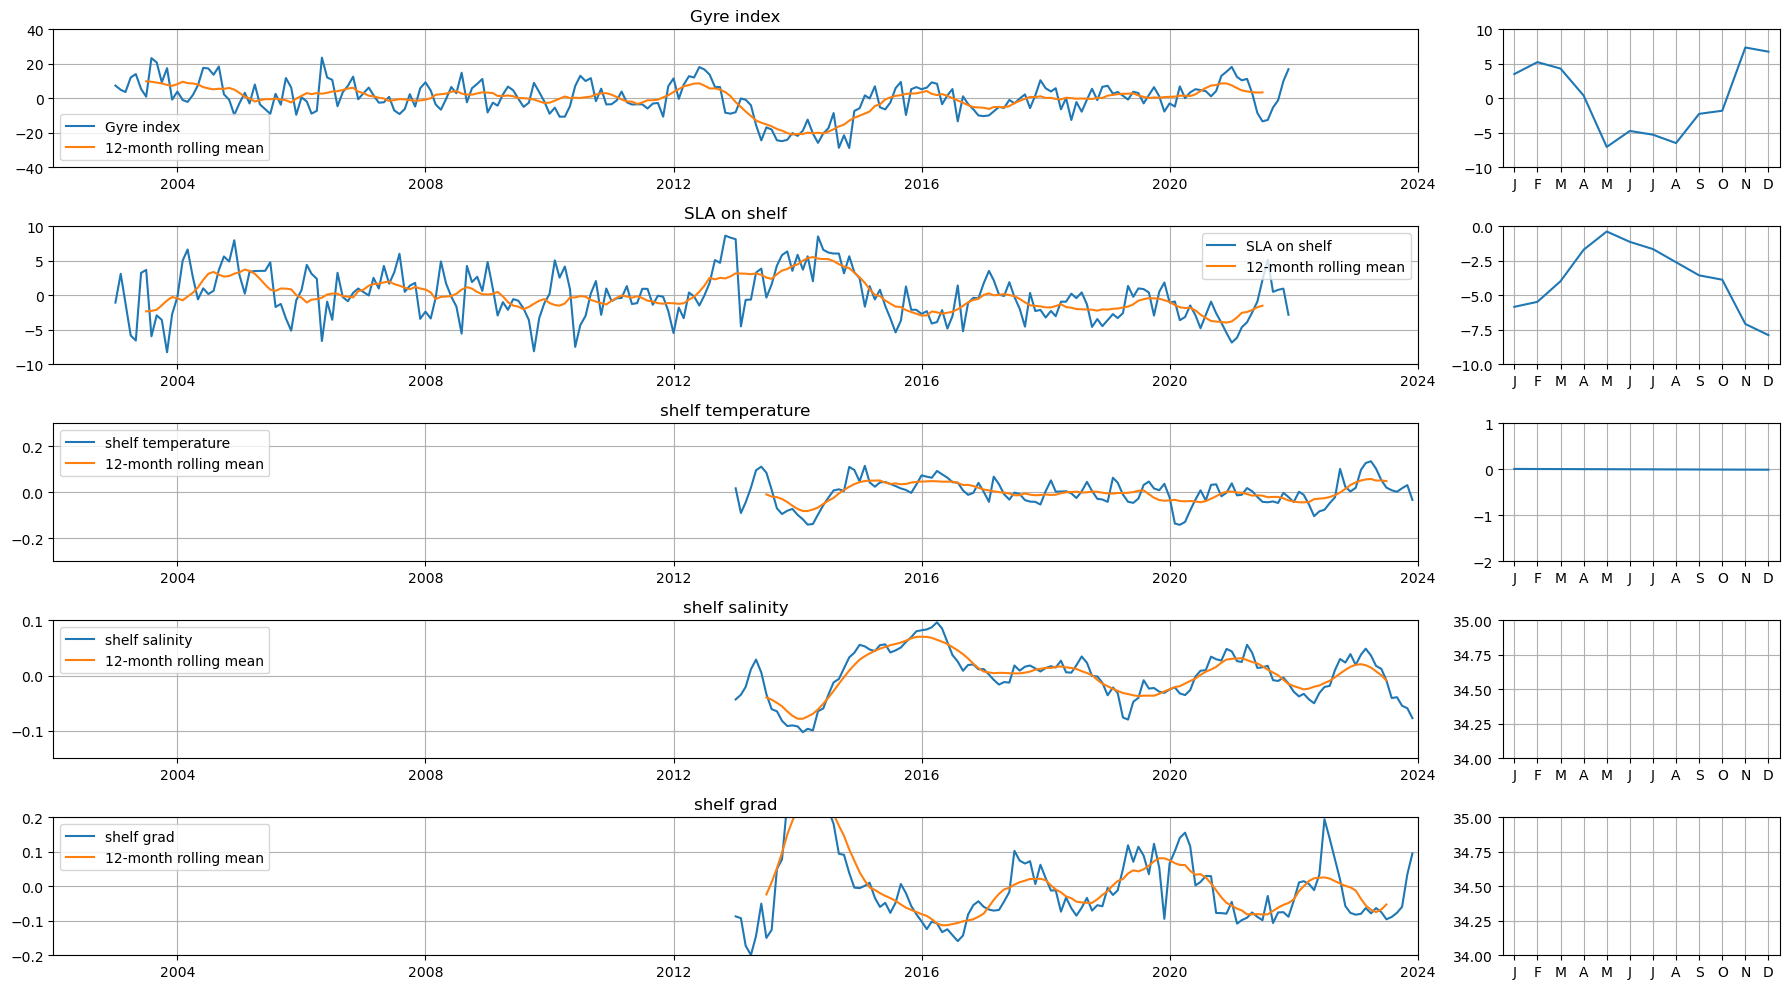

In [70]:
fig = plt.figure(figsize=(18,10))
axs=[]

gs = fig.add_gridspec(5,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])


sd2 = xr.open_dataarray('sigdiff2.nc')

add_row(0,gyre_index,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-10,10])
add_row(1,cssh,'SLA on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])
add_row(2,dt_sthe,'shelf temperature',anom=True,ylim=[-0.3,0.3],ylim_cmt=[-2,1])
add_row(3,dt_ssal,'shelf salinity',anom=True,ylim=[-0.15,0.1],ylim_cmt=[34,35])
add_row(4,sd2,'shelf grad',anom=True,ylim=[-0.2,0.2],ylim_cmt=[34,35])





plt.tight_layout()
print('Rendering..')


In [28]:
var1 = fns.seasonal_anomaly(detrended_vars['Gyre Index'])


lags = np.arange(-12,13,1)
cmat = np.empty((len(detrended_vars),len(lags)))
pmat = np.empty((len(detrended_vars),len(lags)))
lbls = []


In [34]:

for i,key in enumerate(detrended_vars):
    v=fns.seasonal_anomaly(detrended_vars[key])
    lbls.append(key)
    for j,w in enumerate(lags):
        var1_shifted = var1.assign_coords(
            time=pd.to_datetime(var1.time.values) + pd.DateOffset(months=w)
        )
        vw, wv = xr.align(v,var1_shifted)#.shift({'time':w}))
        cmat[i][j] = xr.corr(vw,wv).item()
        #pmat[i][j] = pearsonr(vw, wv)[1]

In [36]:
matt = pd.DataFrame(cmat.T,columns=detrended_vars.keys(),index=[str(n) for n in lags])

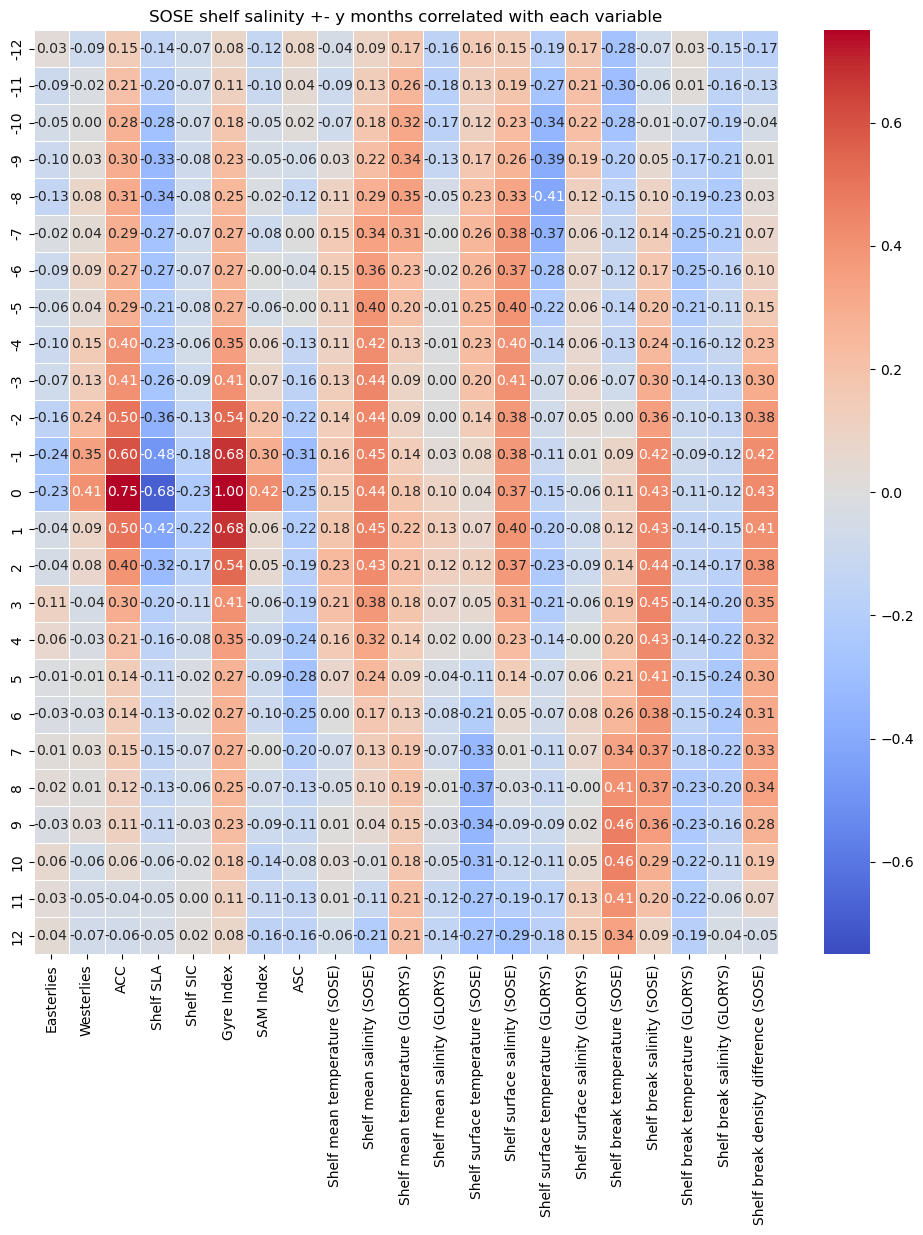

In [38]:
plt.figure(figsize=(12,12))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-0.75,vmax=0.75)
plt.title("SOSE shelf salinity +- y months correlated with each variable")
plt.show()

In [17]:
def mshift(da,m):
    return da.assign_coords(
            time=pd.to_datetime(da.time.values) + pd.DateOffset(months=m)
        )

def laglbl(lag):
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    return txt

In [24]:
#vars = [fns.seasonal_anomaly(var) for var in [westl,eastl,cssh,asc,acc,sam,csic,sthe,ssal,gssh,gyre_index]]#,sigdiff]]
#vars = [fns.seasonal_anomaly(var) for var in [dt_westl,dt_eastl,dt_cssh,dt_asc,dt_acc,dt_sam,dt_csic,dt_sthe,dt_ssal,dt_glorys_theta,dt_glorys_psal,dt_gi]]#dt_gi,sigdiff]]
lags = np.arange(-6,7,1)

cmat = np.empty((len(detrended_vars),len(detrended_vars)))
lmat = np.empty((len(detrended_vars),len(detrended_vars)))
lbls = []

for i,key in enumerate(detrended_vars):
    var1=fns.seasonal_anomaly(detrended_vars[key])
    lbls.append(key)
    cmatl = np.empty((len(lags)))

    for j,k in enumerate(detrended_vars):
        v=fns.seasonal_anomaly(detrended_vars[k])
        for k,w in enumerate(lags):
            vw, wv = xr.align(v,mshift(var1,w))#var1.shift({'time':w}))
            cmatl[k] = xr.corr(vw,wv).item()
        abs_cmatl = np.abs(cmatl)
        cmat[i][j] = cmatl[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]
        lmat[i][j] = lags[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]

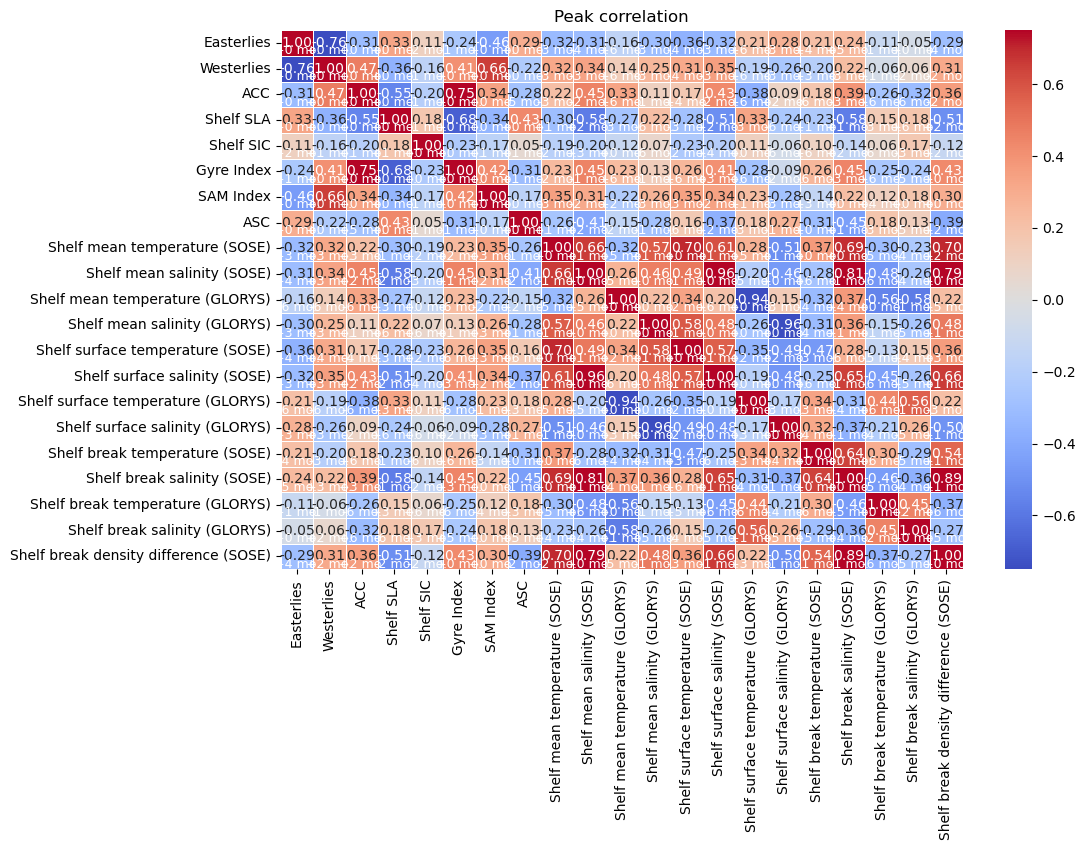

In [25]:
matt = pd.DataFrame(cmat,columns=lbls,index=lbls)

fig,ax = plt.subplots(figsize=(11,7))
sns.heatmap(matt, ax=ax, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-0.75,vmax=0.75)
ax.set_title("Peak correlation")


for i in range (lmat.shape[0]):
  for j in range(lmat.shape[1]):
    lag = lmat[i,j]
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    ax.text(i + 0.5, j + 0.8, txt,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9,
            color='w')

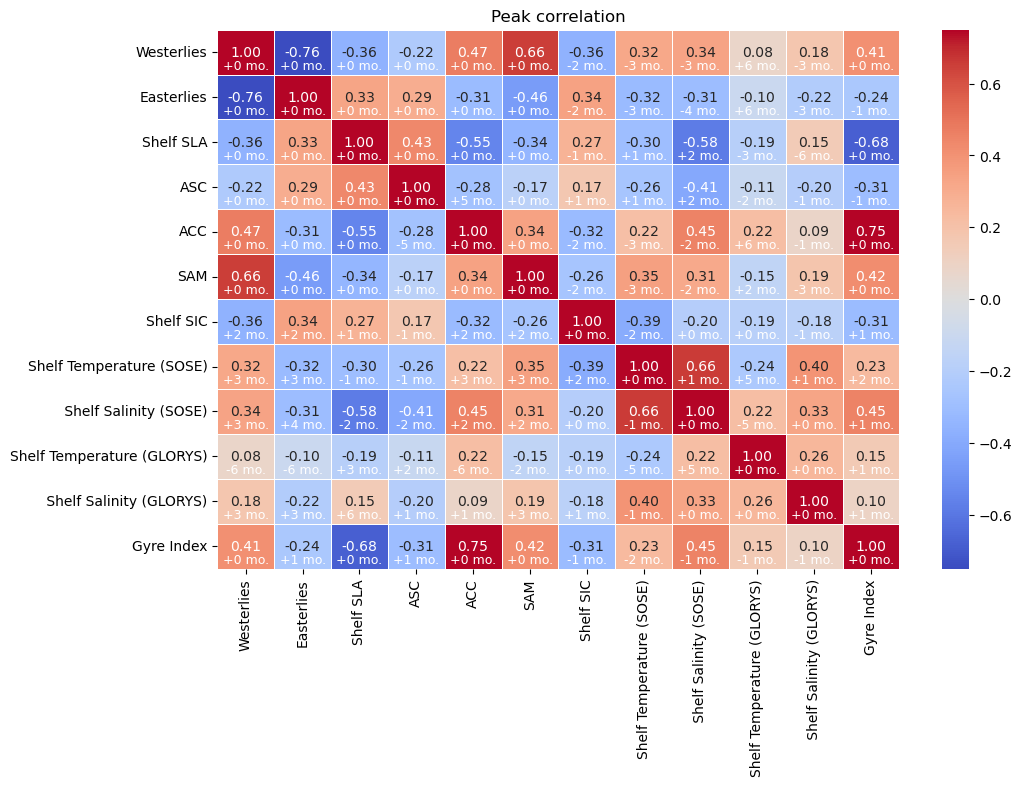

In [ ]:
#lbls = ['Westerlies','Easterlies','Shelf SLA','ASC','ACC','SAM','Shelf SIC','Shelf Temperature (SOSE)',' Shelf Salinity (SOSE)','Shelf Temperature (GLORYS)',' Shelf Salinity (GLORYS)','Gyre Index']#,'sd2']
matt = pd.DataFrame(cmat,columns=lbls,index=lbls)

fig,ax = plt.subplots(figsize=(11,7))
sns.heatmap(matt, ax=ax, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-0.75,vmax=0.75)
ax.set_title("Peak correlation")

#matl = pd.DataFrame(lmat,columns=lbls,index=lbls)
# plt.figure(figsize=(6,4))
# sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-12,vmax=23)
# plt.title("Correlation Heatmap")
# plt.show()

#ax=plt.gca()

for i in range (lmat.shape[0]):
  for j in range(lmat.shape[1]):
    lag = lmat[i,j]
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    ax.text(i + 0.5, j + 0.8, txt,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9,
            color='w')

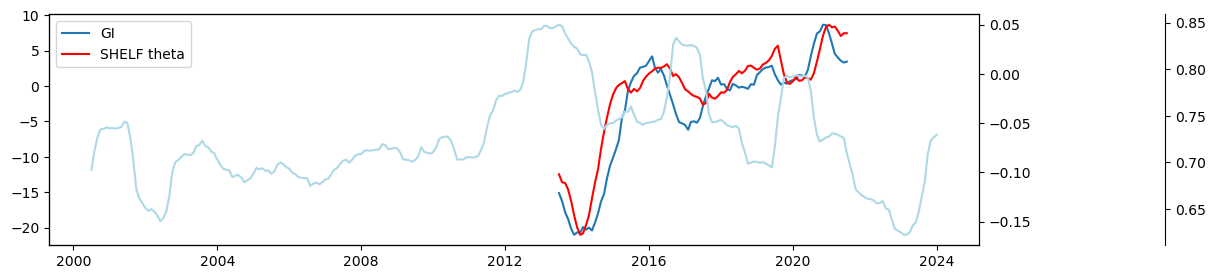

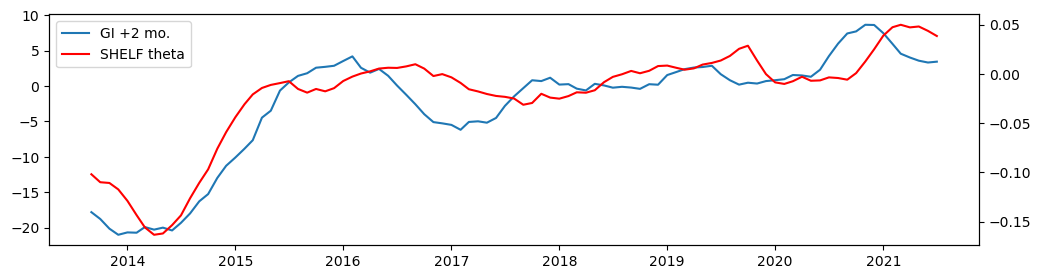

In [ ]:
a = fns.seasonal_anomaly(gyre_index)
alabel='GI'
b = fns.seasonal_anomaly(sthe)
blabel='SHELF theta'
lag=2

a,b = xr.align(a,b)
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')

twin2=ax.twinx()
twin2.spines.right.set_position(("axes", 1.2))

l3 = twin2.plot(csic.time,csic.rolling({'time':12},center=True).mean(),c='lightblue')
ax.legend(l1+l2,[alabel,blabel])

a,b = xr.align(a,mshift(b,lag))
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])

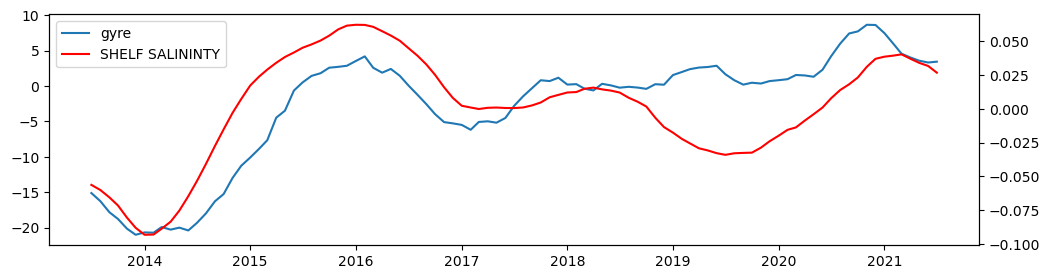

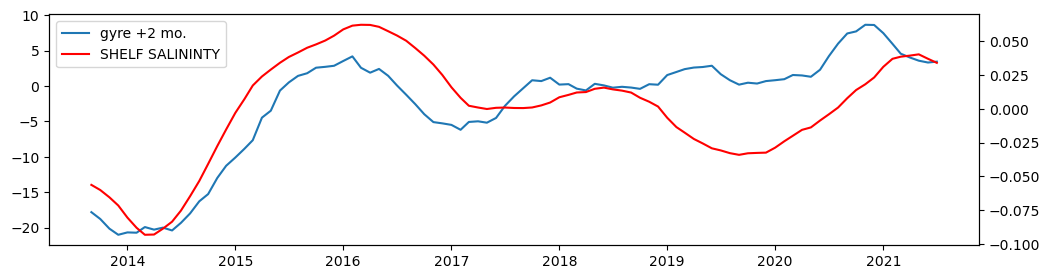

In [ ]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre'
b = fns.seasonal_anomaly(ssal)
blabel='SHELF SALININTY'
lag=2

a,b = xr.align(a,b)
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

a,b = xr.align(a,mshift(b,lag))
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])


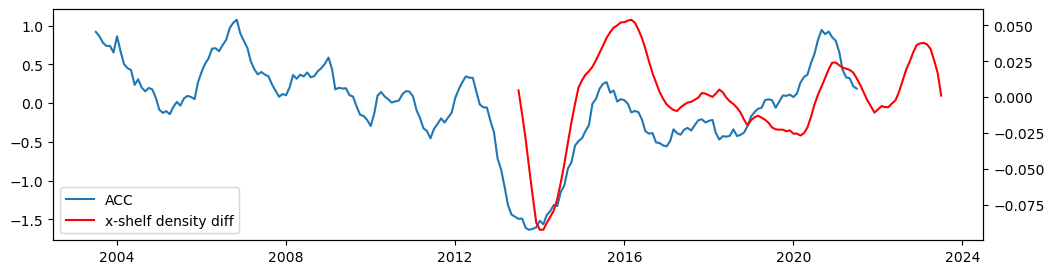

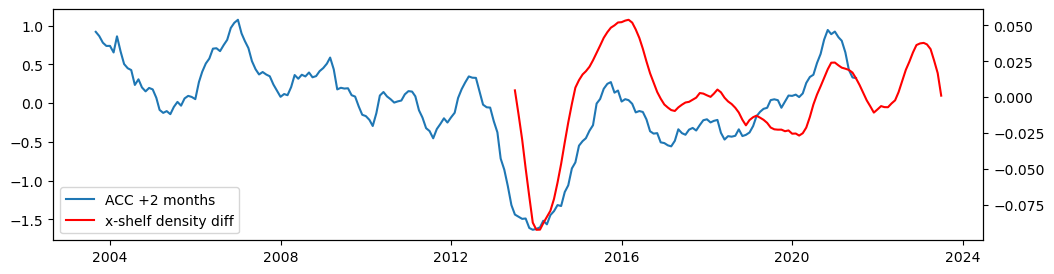

In [46]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

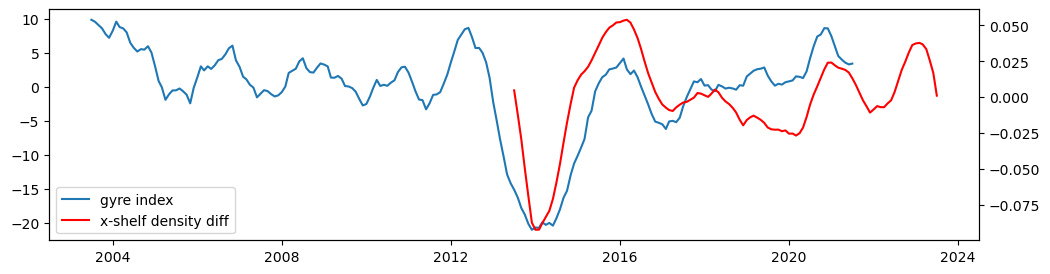

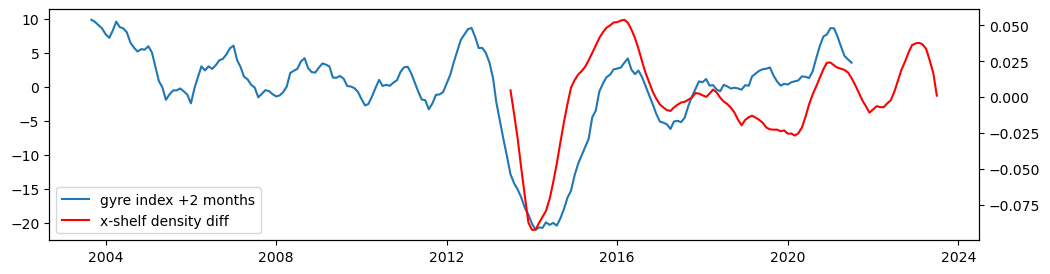

In [47]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre index'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

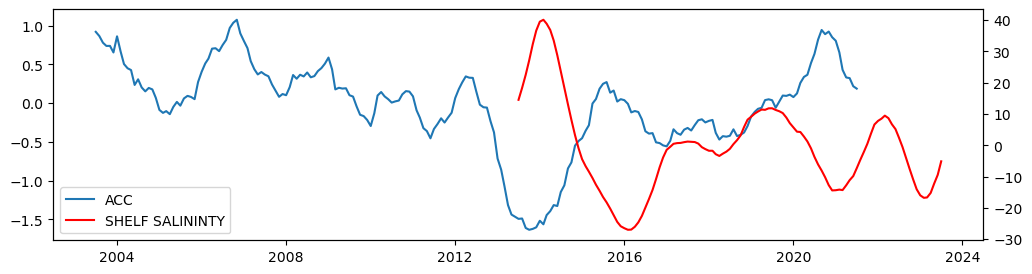

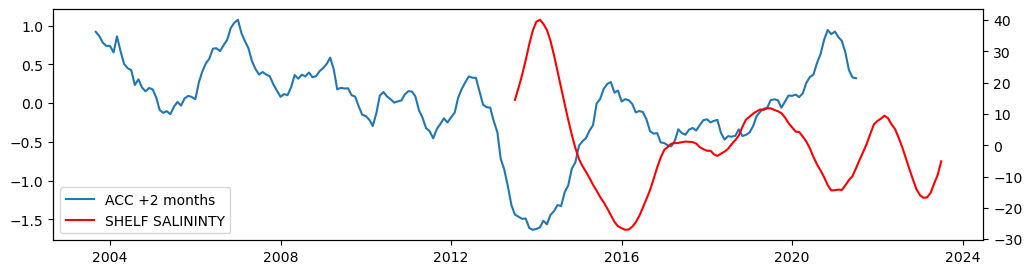

In [48]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sose145.SALT.integrate('Z').mean(['YC']))
blabel='SHELF SALININTY'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

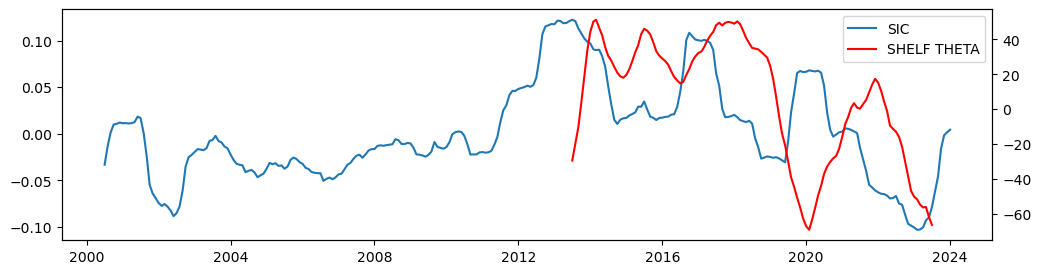

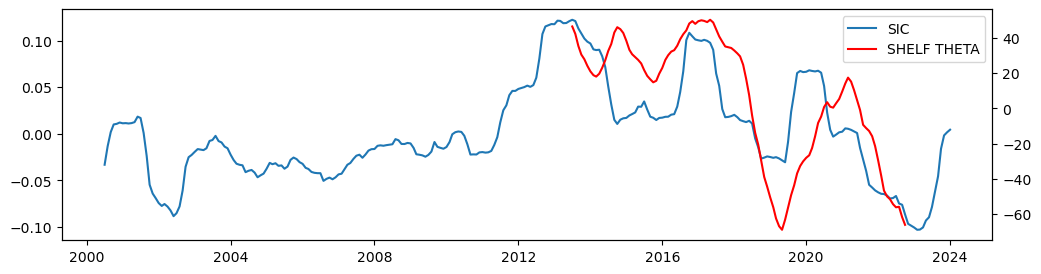

In [49]:
a = fns.seasonal_anomaly(csic)
alabel='SIC'
b = fns.seasonal_anomaly(sose145.THETA.integrate('Z').mean(['YC']))
blabel='SHELF THETA'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.shift({'time':-9}).rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])


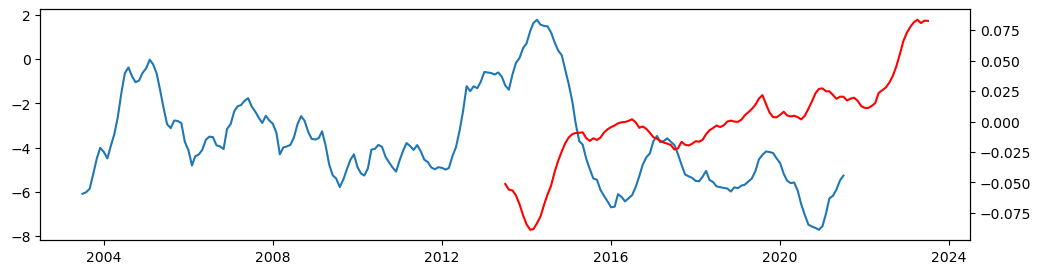

In [50]:
fig, ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(cssh.time,cssh.rolling({'time':12},center=True).mean())
ax.twinx().plot(var1.time,var1.rolling({'time':12},center=True).mean(),c='r')